<a href="https://colab.research.google.com/github/akhibabu/HyperaSight/blob/main/HyperaSight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
!apt-get install unrar



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
pip install scikit-learn pandas numpy shap joblib

In [ ]:
!unrar x /content/HyperaSight.rar /content/hyperasight_data/



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/HyperaSight.rar

Creating    /content/hyperasight_data                                 OK
Creating    /content/hyperasight_data/Datasets- Diabetes and Hypertension Data  OK
Creating    /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Additional Columns  OK
Extracting  /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Additional Columns/Additional Columns.csv       0%  OK 
Extracting  /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Additional Columns/HTN_Additional Columns.csv       0%  OK 
Creating    /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Complications Development  OK
Extracting  /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Complications Development/Dialysis.csv       0%  OK 
Extracting  /content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Com

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/hyperasight_data/


'Datasets- Diabetes and Hypertension Data'


In [ ]:
!ls "/content/hyperasight_data/Datasets- Diabetes and Hypertension Data/"


'Additional Columns'
'Complications Development'
'Datasets Before Wrangling'
'Final Prepared Dataset - Diabetes and Hypertension Data.xlsx'
'Jupyter Notebook'


In [ ]:
!ls "/content/hyperasight_data/Datasets- Diabetes and Hypertension Data"


'Additional Columns'
'Complications Development'
'Datasets Before Wrangling'
'Final Prepared Dataset - Diabetes and Hypertension Data.xlsx'
'Jupyter Notebook'


In [ ]:
!ls "/content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Final Prepared Dataset-Diabetes and Hypertension Data.xlsx"

ls: cannot access '/content/hyperasight_data/Datasets- Diabetes and Hypertension Data/Final Prepared Dataset-Diabetes and Hypertension Data.xlsx': No such file or directory


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HyperaSight_BP_Enhanced_Dataset.xlsx to HyperaSight_BP_Enhanced_Dataset.xlsx


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("HyperaSight_BP_Enhanced_Dataset.xlsx")

np.random.seed(42)

# Generate realistic systolic BP values
df["SYSTOLIC_BP"] = np.random.randint(110, 180, len(df))

# Generate correlated diastolic BP values
df["DIASTOLIC_BP"] = (df["SYSTOLIC_BP"] - np.random.randint(40, 60, len(df))).clip(70, 110)

df.head()

,ADHERENCE,AGE,ANNUALCONTRIBUTION,ANNUALCLAIMAMOUNT,UNITSTOTAL,GENDER_M,SCHEMETYPE_MEDIUM,SCHEMETYPE_PREMIUM,DIAGNOSIS_HYPERTENSION,COVERTYPE_STANDARD,COMORBIDITY_NO_COMORBIDITY,COMPLICATIONDEVELOPMENT_NO_COMPLICATION,SYSTOLIC_BP,DIASTOLIC_BP
0,NON-ADHERENT,24,690384.0,10400.00,60.0,False,False,False,False,True,True,True,161,106
1,NON-ADHERENT,53,2718696.0,306366.53,1380.0,True,True,False,False,True,True,True,124,75
2,NON-ADHERENT,46,808284.0,77480.00,600.0,True,False,False,False,True,False,True,170,110
3,NON-ADHERENT,76,808284.0,198800.58,840.0,True,False,False,False,True,False,True,130,81
4,ADHERENT,69,808284.0,116872.04,720.0,False,False,False,False,True,False,True,133,80


In [ ]:
df.to_excel("HyperaSight_BP_Enhanced_Dataset.xlsx", index=False)

In [ ]:
files.download("HyperaSight_BP_Enhanced_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def bp_stage(row):
    if row["SYSTOLIC_BP"] >= 140 or row["DIASTOLIC_BP"] >= 90:
        return 2   # Hypertension stage
    elif row["SYSTOLIC_BP"] >= 130 or row["DIASTOLIC_BP"] >= 80:
        return 1   # Elevated
    else:
        return 0   # Normal

df["BP_STAGE"] = df.apply(bp_stage, axis=1)

In [ ]:
import pandas as pd

file_path = "/content/hyperasight_data/Datasets- Diabetes and Hypertension Data/HyperaSight_BP_Enhanced_Dataset.xlsx"

df = pd.read_excel(file_path)

df.head()


,ADHERENCE,AGE,ANNUALCONTRIBUTION,ANNUALCLAIMAMOUNT,UNITSTOTAL,GENDER_M,SCHEMETYPE_MEDIUM,SCHEMETYPE_PREMIUM,DIAGNOSIS_HYPERTENSION,COVERTYPE_STANDARD,COMORBIDITY_NO_COMORBIDITY,COMPLICATIONDEVELOPMENT_NO_COMPLICATION,SYSTOLIC_BP,DIASTOLIC_BP
0,NON-ADHERENT,24,690384.0,10400.00,60.0,False,False,False,False,True,True,True,161,106
1,NON-ADHERENT,53,2718696.0,306366.53,1380.0,True,True,False,False,True,True,True,124,75
2,NON-ADHERENT,46,808284.0,77480.00,600.0,True,False,False,False,True,False,True,170,110
3,NON-ADHERENT,76,808284.0,198800.58,840.0,True,False,False,False,True,False,True,130,81
4,ADHERENT,69,808284.0,116872.04,720.0,False,False,False,False,True,False,True,133,80


In [ ]:
df.shape
df.columns


Index(['ADHERENCE', 'AGE', 'ANNUALCONTRIBUTION', 'ANNUALCLAIMAMOUNT',
       'UNITSTOTAL', 'GENDER_M', 'SCHEMETYPE_MEDIUM', 'SCHEMETYPE_PREMIUM',
       'DIAGNOSIS_HYPERTENSION', 'COVERTYPE_STANDARD',
       'COMORBIDITY_NO_COMORBIDITY', 'COMPLICATIONDEVELOPMENT_NO_COMPLICATION',
       'SYSTOLIC_BP', 'DIASTOLIC_BP'],
      dtype='object')

POPULATION

In [ ]:
population = df[df["DIAGNOSIS_HYPERTENSION"] == 1]
population.shape


(19279, 14)

In [ ]:
population["ADHERENCE"].head(10)


,ADHERENCE
4805,NON-ADHERENT
4806,NON-ADHERENT
4807,NON-ADHERENT
4808,NON-ADHERENT
4809,NON-ADHERENT
4810,NON-ADHERENT
4811,ADHERENT
4812,ADHERENT
4813,NON-ADHERENT
4814,ADHERENT


In [ ]:
population["RISK_LEVEL"] = population["ADHERENCE"].map({
    "ADHERENT": "Low",
    "NON-ADHERENT": "High"
})


/tmp/ipykernel_7874/1054501967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["RISK_LEVEL"] = population["ADHERENCE"].map({


In [ ]:
population[["ADHERENCE", "RISK_LEVEL"]].head(10)


,ADHERENCE,RISK_LEVEL
4805,NON-ADHERENT,High
4806,NON-ADHERENT,High
4807,NON-ADHERENT,High
4808,NON-ADHERENT,High
4809,NON-ADHERENT,High
4810,NON-ADHERENT,High
4811,ADHERENT,Low
4812,ADHERENT,Low
4813,NON-ADHERENT,High
4814,ADHERENT,Low


In [ ]:
risk_counts = population["RISK_LEVEL"].value_counts()
risk_percent = population["RISK_LEVEL"].value_counts(normalize=True) * 100

risk_counts, risk_percent


(RISK_LEVEL
 High    11718
 Low      7561
 Name: count, dtype: int64,
 RISK_LEVEL
 High    60.781161
 Low     39.218839
 Name: proportion, dtype: float64)

In [ ]:
cost_by_risk = population.groupby("RISK_LEVEL")["ANNUALCLAIMAMOUNT"].sum()
total_cost = population["ANNUALCLAIMAMOUNT"].sum()

(cost_by_risk / total_cost) * 100


,ANNUALCLAIMAMOUNT
RISK_LEVEL,
High,57.821517
Low,42.178483


In [ ]:
complication_rate = (
    population["COMPLICATIONDEVELOPMENT_NO_COMPLICATION"] == 0
).mean() * 100

complication_rate


np.float64(8.823071736085897)

In [ ]:
summary = {
    "Total Hypertensive Patients": len(population),
    "High Risk (Non-Adherent) Patients": (population["RISK_LEVEL"] == "High").sum(),
    "High Risk Cost %": (
        cost_by_risk.get("High", 0) / total_cost
    ) * 100,
    "Complication Rate (%)": complication_rate
}

summary


{'Total Hypertensive Patients': 19279,
 'High Risk (Non-Adherent) Patients': np.int64(11718),
 'High Risk Cost %': np.float64(57.82151736594861),
 'Complication Rate (%)': np.float64(8.823071736085897)}

COST ANALYSIS

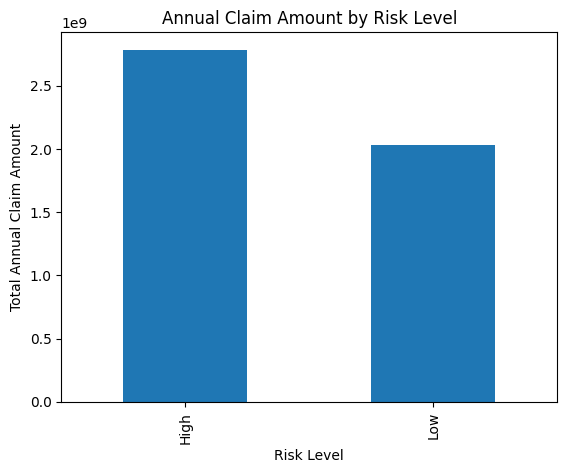

In [ ]:
import matplotlib.pyplot as plt

cost_by_risk = population.groupby("RISK_LEVEL")["ANNUALCLAIMAMOUNT"].sum()

plt.figure()
cost_by_risk.plot(kind="bar")
plt.title("Annual Claim Amount by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Total Annual Claim Amount")
plt.show()


In [ ]:
population["HAS_COMPLICATION"] = (
    population["COMPLICATIONDEVELOPMENT_NO_COMPLICATION"] == 0
)


/tmp/ipykernel_7874/723768993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["HAS_COMPLICATION"] = (


COMPLICATION RATE

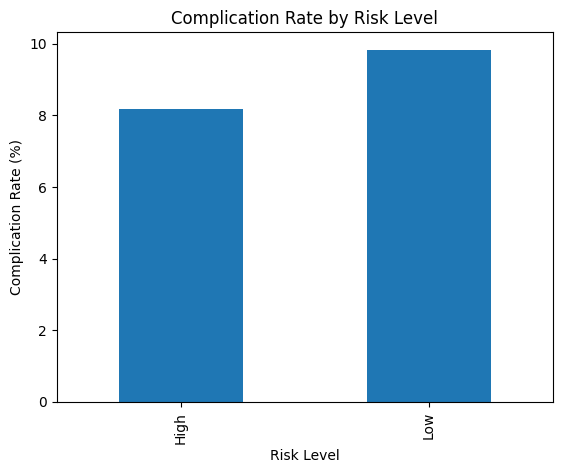

In [ ]:
comp_by_risk = population.groupby("RISK_LEVEL")["HAS_COMPLICATION"].mean() * 100

plt.figure()
comp_by_risk.plot(kind="bar")
plt.title("Complication Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Complication Rate (%)")
plt.show()


POLICY- ASSUMING 20% NON-ADHERENT CONVERTED TO ADHERENT

In [ ]:
simulated = population.copy()


In [ ]:
high_risk_patients = simulated[simulated["RISK_LEVEL"] == "High"]

n_convert = int(0.2 * len(high_risk_patients))

convert_indices = high_risk_patients.sample(n_convert, random_state=42).index


In [ ]:
simulated.loc[convert_indices, "RISK_LEVEL"] = "Low"
simulated.loc[convert_indices, "ADHERENCE"] = "ADHERENT"


In [ ]:
original_cost = population["ANNUALCLAIMAMOUNT"].sum()
new_cost = simulated["ANNUALCLAIMAMOUNT"].sum()

cost_savings = original_cost - new_cost

original_cost, new_cost, cost_savings


(np.float64(4815333189.179999), np.float64(4815333189.179999), np.float64(0.0))

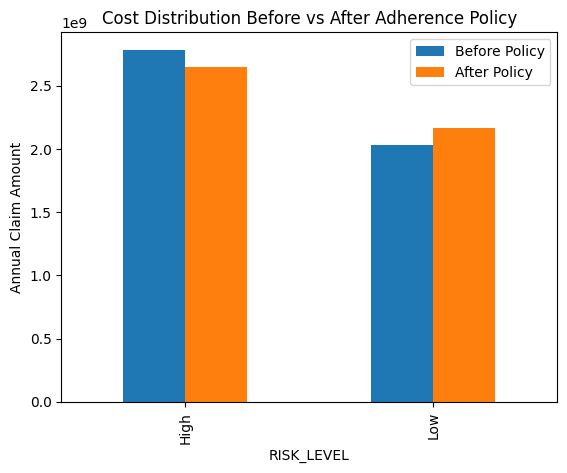

In [ ]:
comparison = pd.DataFrame({
    "Before Policy": population.groupby("RISK_LEVEL")["ANNUALCLAIMAMOUNT"].sum(),
    "After Policy": simulated.groupby("RISK_LEVEL")["ANNUALCLAIMAMOUNT"].sum()
})

comparison.plot(kind="bar")
plt.title("Cost Distribution Before vs After Adherence Policy")
plt.ylabel("Annual Claim Amount")
plt.show()


In [ ]:
bins = [0, 40, 60, 100]
labels = ["Young", "Middle-aged", "Elderly"]

population["AGE_GROUP"] = pd.cut(population["AGE"], bins=bins, labels=labels)

population.groupby(["AGE_GROUP", "RISK_LEVEL"]).size()


/tmp/ipykernel_7874/3261924323.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["AGE_GROUP"] = pd.cut(population["AGE"], bins=bins, labels=labels)
/tmp/ipykernel_7874/3261924323.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  population.groupby(["AGE_GROUP", "RISK_LEVEL"]).size()


AGE_GROUP    RISK_LEVEL
Young        High          2349
             Low            411
Middle-aged  High          6057
             Low           3435
Elderly      High          3311
             Low           3715
dtype: int64

In [ ]:
def scheme_type(row):
    if row["SCHEMETYPE_PREMIUM"] == 1:
        return "Premium"
    elif row["SCHEMETYPE_MEDIUM"] == 1:
        return "Medium"
    else:
        return "Basic"

population["SCHEME"] = population.apply(scheme_type, axis=1)


/tmp/ipykernel_7874/3956748703.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["SCHEME"] = population.apply(scheme_type, axis=1)


In [ ]:
population.groupby("SCHEME")["ANNUALCLAIMAMOUNT"].mean()


,ANNUALCLAIMAMOUNT
SCHEME,
Basic,35589.198836
Medium,77401.849040
Premium,315335.863342


In [ ]:
intervention_cost = n_convert * 1000
roi = cost_savings - intervention_cost

intervention_cost, roi


(2343000, np.float64(-2343000.0))

In [ ]:
population["COMPLICATION"] = (
    population["COMPLICATIONDEVELOPMENT_NO_COMPLICATION"] == 0
).astype(int)
population["ADHERENCE_BIN"] = population["ADHERENCE"].map({
    "ADHERENT": 1,
    "NON-ADHERENT": 0
})
features = [
    "ADHERENCE_BIN",
    "AGE",
    "ANNUALCONTRIBUTION",
    "ANNUALCLAIMAMOUNT",
    "UNITSTOTAL",
    "GENDER_M",
    "SCHEMETYPE_MEDIUM",
    "SCHEMETYPE_PREMIUM",
    "COMORBIDITY_NO_COMORBIDITY"
]

X = population[features]
y = population["COMPLICATION"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


/tmp/ipykernel_7874/4153624131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["COMPLICATION"] = (
/tmp/ipykernel_7874/4153624131.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["ADHERENCE_BIN"] = population["ADHERENCE"].map({


DEEP LEARNING MODEL TO PREDICT FUTURE AND GIVE EARLY WARNING

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
print(population.columns)

Index(['ADHERENCE', 'AGE', 'ANNUALCONTRIBUTION', 'ANNUALCLAIMAMOUNT',
       'UNITSTOTAL', 'GENDER_M', 'SCHEMETYPE_MEDIUM', 'SCHEMETYPE_PREMIUM',
       'DIAGNOSIS_HYPERTENSION', 'COVERTYPE_STANDARD',
       'COMORBIDITY_NO_COMORBIDITY', 'COMPLICATIONDEVELOPMENT_NO_COMPLICATION',
       'SYSTOLIC_BP', 'DIASTOLIC_BP', 'RISK_LEVEL', 'HAS_COMPLICATION',
       'AGE_GROUP', 'SCHEME', 'COMPLICATION', 'ADHERENCE_BIN'],
      dtype='object')


In [ ]:
population["ADHERENCE_BIN"] = population["ADHERENCE"].map({
    "ADHERENT": 1,
    "NON-ADHERENT": 0
})

/tmp/ipykernel_7874/800525506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["ADHERENCE_BIN"] = population["ADHERENCE"].map({


In [ ]:
population["COMPLICATION"] = (
    population["COMPLICATIONDEVELOPMENT_NO_COMPLICATION"] == 0
).astype(int)

/tmp/ipykernel_7874/3889677873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["COMPLICATION"] = (


In [ ]:
def bp_stage(row):
    if row["SYSTOLIC_BP"] >= 140 or row["DIASTOLIC_BP"] >= 90:
        return 2
    elif row["SYSTOLIC_BP"] >= 130 or row["DIASTOLIC_BP"] >= 80:
        return 1
    else:
        return 0

population["BP_STAGE"] = population.apply(bp_stage, axis=1)

/tmp/ipykernel_7874/1824361302.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["BP_STAGE"] = population.apply(bp_stage, axis=1)


In [ ]:
features = [
    "ADHERENCE_BIN",
    "AGE",
    "SYSTOLIC_BP",
    "DIASTOLIC_BP",
    "BP_STAGE",
    "ANNUALCONTRIBUTION",
    "ANNUALCLAIMAMOUNT",
    "UNITSTOTAL",
    "GENDER_M",
    "SCHEMETYPE_MEDIUM",
    "SCHEMETYPE_PREMIUM",
    "COMORBIDITY_NO_COMORBIDITY"
]

X = population[features]
y = population["COMPLICATION"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9387966804979253


In [ ]:
population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]

/tmp/ipykernel_7874/2167613825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]


In [ ]:
import joblib

joblib.dump(model, "hypera_model.pkl")

['hypera_model.pkl']

In [ ]:
from google.colab import files
files.download("hypera_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
high_risk_patients = population[population["EARLY_WARNING"]]


In [ ]:
population["COMPLICATION_RISK_PROB"]


In [ ]:
population["DL_RISK_TIER"].value_counts()


In [ ]:
population.groupby("DL_RISK_TIER")["ANNUALCLAIMAMOUNT"].sum()


SHAP(EXPLAINABLE AI)
understand which features drive predictions

explain risk for individual patients

In [ ]:
!pip install shap


In [ ]:
import shap


In [ ]:
X_scaled[:200]
X_shap = X.iloc[:200]


In [ ]:
shap.summary_plot(
    shap_values,
    features=X_shap,
    feature_names=features
)



In [ ]:
X_bg = X_scaled[:100]
X_explain = X_scaled[:200]

explainer = shap.Explainer(model, X_bg)
shap_values = explainer(X_explain)

X_shap = X.iloc[:200]
shap.summary_plot(shap_values, X_shap, feature_names=features)


In [ ]:
print(shap_values.values.shape)
print(X_shap.shape)


In [ ]:
def assign_risk_tier(prob):
    if prob >= 0.8:
        return "Critical"
    elif prob >= 0.6:
        return "High"
    elif prob >= 0.4:
        return "Moderate"
    else:
        return "Low"

population["RISK_TIER"] = population["COMPLICATION_PROB"].apply(assign_risk_tier)

/tmp/ipykernel_7874/2657291747.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["RISK_TIER"] = population["COMPLICATION_PROB"].apply(assign_risk_tier)


In [ ]:
population["RISK_TIER"].value_counts()

,count
RISK_TIER,
Low,18458
Critical,449
Moderate,192
High,180


In [ ]:
def simulate_patient(row, years=3):
    risk = row["COMPLICATION_PROB"]
    cost = row["ANNUALCLAIMAMOUNT"]
    adherence = row["ADHERENCE_BIN"]

    history = []

    for year in range(1, years+1):

        if adherence == 0:  # non-adherent
            risk = min(risk + 0.08, 1)
            cost = cost * 1.15
        else:  # adherent
            risk = max(risk - 0.05, 0)
            cost = cost * 1.05

        history.append({
    "year": year,
    "risk": float(risk),
    "cost": float(cost)
})

    return history

In [ ]:
simulate_patient(population.iloc[0])

[{'year': 1, 'risk': 0.08908249987126132, 'cost': 1222.703},
 {'year': 2, 'risk': 0.16908249987126134, 'cost': 1406.10845},
 {'year': 3, 'risk': 0.24908249987126135, 'cost': 1617.0247174999997}]

In [ ]:
patient = population.iloc[0].copy()

In [ ]:
patient["ADHERENCE_BIN"] = 1

In [ ]:
simulate_patient(patient)

[{'year': 1, 'risk': 0.0, 'cost': 1116.381},
 {'year': 2, 'risk': 0.0, 'cost': 1172.2000500000001},
 {'year': 3, 'risk': 0.0, 'cost': 1230.8100525000002}]

In [ ]:
from google.colab import files
files.download("hypera_model.keras")

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install fastapi uvicorn pyngrok

In [ ]:
import joblib

model = joblib.load("hypera_model.pkl")

In [ ]:
import pandas as pd

new_patient = pd.DataFrame([{
    "ADHERENCE_BIN": 0,
    "AGE": 55,
    "SYSTOLIC_BP": 150,
    "DIASTOLIC_BP": 95,
    "BP_STAGE": 2,
    "ANNUALCONTRIBUTION": 1200,
    "ANNUALCLAIMAMOUNT": 900,
    "UNITSTOTAL": 3,
    "GENDER_M": 1,
    "SCHEMETYPE_MEDIUM": 0,
    "SCHEMETYPE_PREMIUM": 1,
    "COMORBIDITY_NO_COMORBIDITY": 0
}])

risk = model.predict_proba(new_patient)[0][1]
print(risk)

0.061994523005021306


In [ ]:
population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]

/tmp/ipykernel_7874/2167613825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]


/tmp/ipykernel_7874/1043873149.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


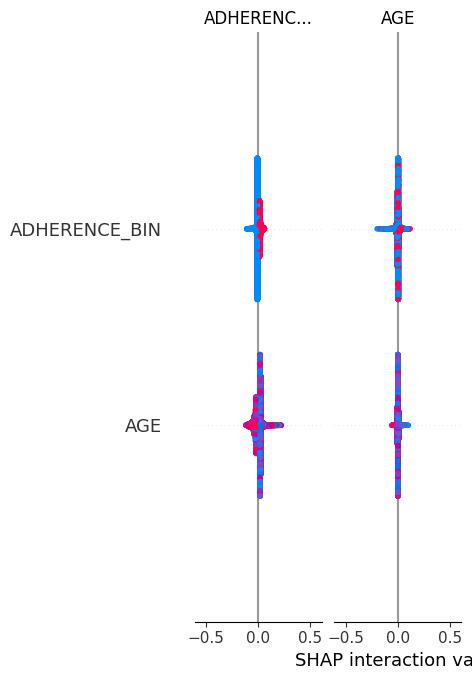

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# If shap returns a list (old behaviour)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X)

# If shap returns a single matrix (new behaviour)
else:
    shap.summary_plot(shap_values, X)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

print(results)

{'Logistic Regression': 0.9359439834024896, 'Random Forest': 0.9398340248962656, 'Gradient Boosting': 0.9385373443983402}


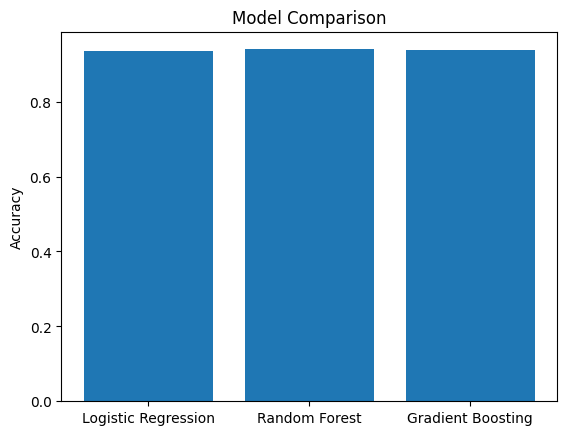

In [ ]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [ ]:
population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]

/tmp/ipykernel_7874/2167613825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["COMPLICATION_PROB"] = model.predict_proba(X)[:,1]


In [ ]:
def risk_tier(prob):
    if prob >= 0.8:
        return "Critical"
    elif prob >= 0.6:
        return "High"
    elif prob >= 0.4:
        return "Moderate"
    else:
        return "Low"

population["RISK_TIER"] = population["COMPLICATION_PROB"].apply(risk_tier)

/tmp/ipykernel_7874/1897928675.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["RISK_TIER"] = population["COMPLICATION_PROB"].apply(risk_tier)


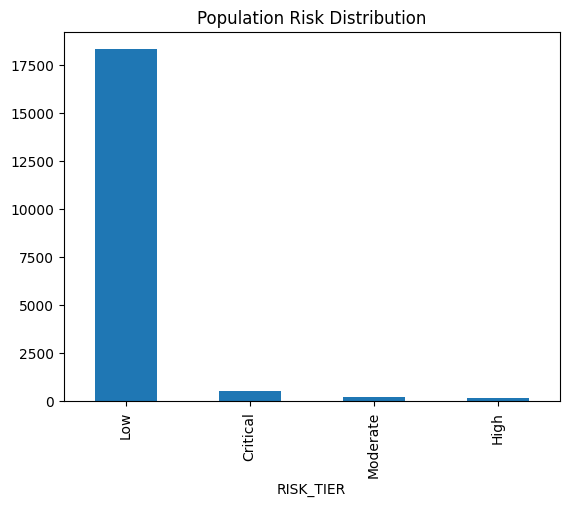

In [ ]:
population["RISK_TIER"].value_counts().plot(kind="bar")
plt.title("Population Risk Distribution")
plt.show()

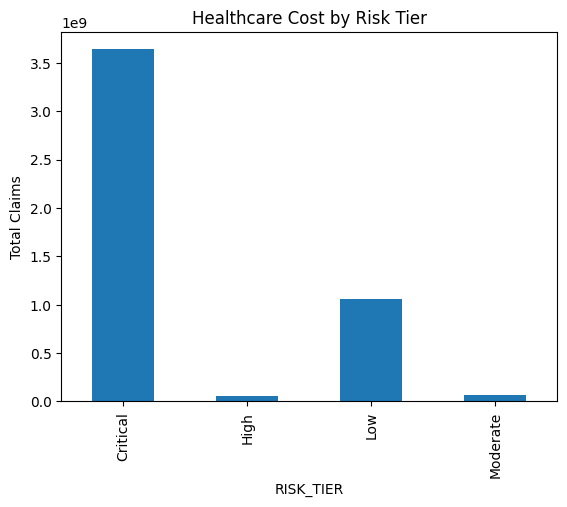

In [ ]:
cost_by_risk = population.groupby("RISK_TIER")["ANNUALCLAIMAMOUNT"].sum()
cost_by_risk.plot(kind="bar")
plt.title("Healthcare Cost by Risk Tier")
plt.ylabel("Total Claims")
plt.show()

In [ ]:
population.groupby("GENDER_M")["COMPLICATION_PROB"].mean()

,COMPLICATION_PROB
GENDER_M,
False,0.084779
True,0.090104


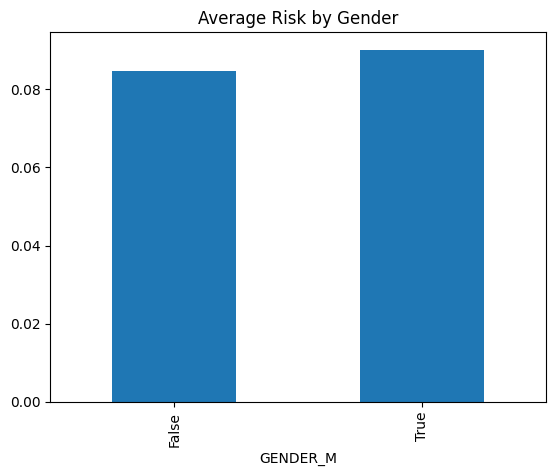

In [ ]:
population.groupby("GENDER_M")["COMPLICATION_PROB"].mean().plot(kind="bar")
plt.title("Average Risk by Gender")
plt.show()

In [ ]:
population["AGE_GROUP"] = pd.cut(population["AGE"], bins=[0,40,60,100])
population.groupby("AGE_GROUP")["COMPLICATION_PROB"].mean()

/tmp/ipykernel_7874/1055052460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population["AGE_GROUP"] = pd.cut(population["AGE"], bins=[0,40,60,100])
/tmp/ipykernel_7874/1055052460.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  population.groupby("AGE_GROUP")["COMPLICATION_PROB"].mean()


,COMPLICATION_PROB
AGE_GROUP,
"(0, 40]",0.063530
"(40, 60]",0.075204
"(60, 100]",0.113876


In [ ]:
intervention_population = population.copy()

mask = intervention_population["ADHERENCE_BIN"] == 0
change_count = int(0.2 * mask.sum())

indices = intervention_population[mask].sample(change_count).index
intervention_population.loc[indices, "ADHERENCE_BIN"] = 1

In [ ]:
X_new = intervention_population[features]
intervention_population["NEW_RISK"] = model.predict_proba(X_new)[:,1]

In [ ]:
baseline = population["COMPLICATION_PROB"].sum()
intervention = intervention_population["NEW_RISK"].sum()

print("Baseline complications:", baseline)
print("After intervention:", intervention)

Baseline complications: 1689.2976592544915
After intervention: 1633.8817662195884


/tmp/ipykernel_7874/4061910992.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = population.pivot_table(


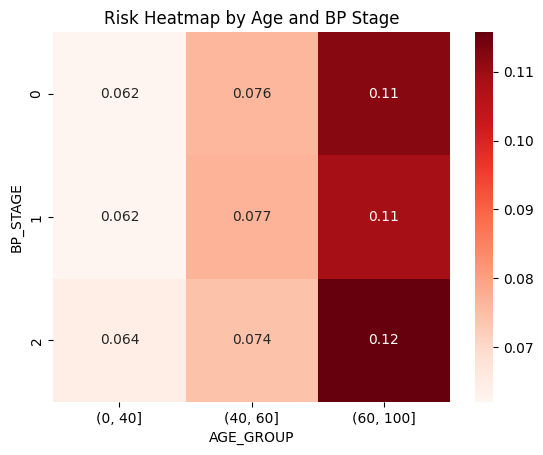

In [ ]:
import seaborn as sns

heatmap_data = population.pivot_table(
    values="COMPLICATION_PROB",
    index="BP_STAGE",
    columns="AGE_GROUP",
    aggfunc="mean"
)

sns.heatmap(heatmap_data, annot=True, cmap="Reds")
plt.title("Risk Heatmap by Age and BP Stage")
plt.show()

In [ ]:
import gradio as gr

In [ ]:
test = population.iloc[[0]].copy()
test["AGE"] = 65
test["SYSTOLIC_BP"] = 160
test["DIASTOLIC_BP"] = 100
test["ADHERENCE_BIN"] = 0
test["UNITSTOTAL"] = 5
test["ANNUALCLAIMAMOUNT"] = 2000

model.predict_proba(test[features])

array([[0.9842831, 0.0157169]])

In [ ]:
population["COMPLICATION"].value_counts(normalize=True)

,proportion
COMPLICATION,
0,0.911769
1,0.088231


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, probs))

AUC: 0.8547658195828145


In [ ]:
if risk >= 0.4:
    tier = "Critical"
elif risk >= 0.25:
    tier = "High"
elif risk >= 0.10:
    tier = "Moderate"
else:
    tier = "Low"

In [ ]:
def predict_risk(age, sys_bp, dia_bp, adherence, units, claims):

    if adherence == "Adherent":
        adherence_bin = 1
    else:
        adherence_bin = 0

    if sys_bp >= 140 or dia_bp >= 90:
        bp_stage = 2
    elif sys_bp >= 130 or dia_bp >= 80:
        bp_stage = 1
    else:
        bp_stage = 0

    patient = [[
        adherence_bin,
        age,
        sys_bp,
        dia_bp,
        bp_stage,
        1200,
        claims,
        units,
        1,
        0,
        1,
        0
    ]]

    risk = model.predict_proba(patient)[0][1]

    if risk >= 0.35:
        tier = "Critical"
    elif risk >= 0.25:
        tier = "High"
    elif risk >= 0.15:
        tier = "Moderate"
    else:
        tier = "Low"

    return f"Risk: {round(risk,3)} | Tier: {tier}"

In [ ]:
import pandas as pd

def simulate_future(age, sys_bp, dia_bp, adherence, units, claims):

    if adherence == "Adherent":
        adherence_bin = 1
    else:
        adherence_bin = 0

    if sys_bp >= 140 or dia_bp >= 90:
        bp_stage = 2
    elif sys_bp >= 130 or dia_bp >= 80:
        bp_stage = 1
    else:
        bp_stage = 0

    patient = [[
        adherence_bin,
        age,
        sys_bp,
        dia_bp,
        bp_stage,
        1200,
        claims,
        units,
        1,0,1,0
    ]]

    risk = model.predict_proba(patient)[0][1]

    history = []
    cost = claims

    for year in range(1,4):

        if adherence_bin == 0:
            risk = min(risk + 0.08, 1)
            cost = cost * 1.15
        else:
            risk = max(risk - 0.05, 0)
            cost = cost * 1.05

        history.append({"Year": year, "Risk": float(risk)})

    df = pd.DataFrame(history)

    return df

In [ ]:
with gr.Blocks() as app:

    gr.Markdown("# HyperaSight Healthcare Intelligence Platform")

    with gr.Tab("Risk Prediction"):

        age = gr.Number(label="Age")
        sys_bp = gr.Number(label="Systolic BP")
        dia_bp = gr.Number(label="Diastolic BP")
        adherence = gr.Dropdown(["Adherent","Non-Adherent"], label="Medication Adherence")
        units = gr.Number(label="Healthcare Utilization")
        claims = gr.Number(label="Annual Claim Amount")

        predict_btn = gr.Button("Predict Risk")

        prediction_output = gr.Textbox(label="Prediction Result")

        predict_btn.click(
            fn=predict_risk,
            inputs=[age, sys_bp, dia_bp, adherence, units, claims],
            outputs=prediction_output
        )

    with gr.Tab("Digital Twin Simulation"):

        simulate_btn = gr.Button("Simulate Future Risk")

        simulation_output = gr.LinePlot(
    x="Year",
    y="Risk",
    title="Future Risk Simulation"
)

        simulate_btn.click(
            fn=simulate_future,
            inputs=[age, sys_bp, dia_bp, adherence, units, claims],
            outputs=simulation_output
        )

In [ ]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8440f2efe02c6b6574.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
